<img style="float: right;" src="https://www.h-ka.de/typo3conf/ext/in2template/Resources/Public/Images/Icons/Favicons/favicon-256x256.png">

# Implementing a Neural Network

In this exercise we will develop a neural network with fully-connected layers to perform classification, and test it out on the CIFAR-10 dataset.

The original code for this exercise was published as an assignment in the [CS231n](http://cs231n.stanford.edu/index.html) course at Uni Standford. The code was modified to fit the syllabus for the lecture "[Neuronale Netze in Bildverarbeitung](https://www.h-ka.de/fileadmin/Hochschule_Karlsruhe_HKA/Informationsmaterialien/HKA_FK-EIT_Sem7_NeuronaleNetze_01.pdf)" at HKA.

## Student Details:

- FirstName: Jan
- LastName: Hoegen
- MatriculationNumber: 82358
----------

In [20]:
CIFAR10_DIR = 'datasets/cifar-10-batches-py'

In [21]:
# A bit of setup

import numpy as np
import matplotlib.pyplot as plt

from EITB712M.classifiers.neural_net import TwoLayerNet

# This is a bit of magic to make matplotlib figures appear inline in the notebook rather than in a new window.
%matplotlib inline
plt.rcParams['figure.figsize'] = (10.0, 8.0) # set default size of plots
plt.rcParams['image.interpolation'] = 'nearest'
plt.rcParams['image.cmap'] = 'gray'

# for auto-reloading external modules see http://stackoverflow.com/questions/1907993/autoreload-of-modules-in-ipython
%load_ext autoreload
%autoreload 2

def rel_error(x, y):
    """ returns relative error """
    return np.max(np.abs(x - y) / (np.maximum(1e-8, np.abs(x) + np.abs(y))))

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


We will use the class `TwoLayerNet` in the file `EITB712M/classifiers/neural_net.py` to represent instances of our network. The network parameters are stored in the instance variable `self.params` where keys are string parameter names and values are numpy arrays. Below, we initialize toy data and a toy model that we will use to develop your implementation.

In [22]:
# Create a small net and some toy data to check your implementations.
# Note that we set the random seed for repeatable experiments.

input_size = 4
hidden_size = 10
num_classes = 3
num_inputs = 5

def init_toy_model():
    np.random.seed(0)
    return TwoLayerNet(input_size, hidden_size, num_classes, std=1e-1)

def init_toy_data():
    np.random.seed(1)
    X = 10 * np.random.randn(num_inputs, input_size)
    y = np.array([0, 1, 2, 2, 1])
    return X, y

net = init_toy_model()
X, y = init_toy_data()
print(X)

[[ 16.24345364  -6.11756414  -5.28171752 -10.72968622]
 [  8.65407629 -23.01538697  17.44811764  -7.61206901]
 [  3.19039096  -2.49370375  14.62107937 -20.60140709]
 [ -3.22417204  -3.84054355  11.33769442 -10.99891267]
 [ -1.72428208  -8.77858418   0.42213747   5.82815214]]


# Forward pass: compute scores
<span style="color:blue">**Open the file `EITB712M/classifiers/neural_net.py` and look at the method `TwoLayerNet.loss`.**</span>

This function is very similar to the loss functions you have written for the MSVM exercise: It takes the data and weights and computes the class scores, the loss, and the gradients on the parameters.

<span style="color:blue">**Implement the first part of the forward pass, which uses the weights and biases to compute the scores for all inputs.**</span>

Remember: We want to implement a two layer model. Both layers are fully connected. The first layer uses a RELU activation, the second layer is a linear classifier. Hence you want to implement the following scoring function in the forward path:

$f=W_2 max(0,W_1 x + b_1)+b_2$

In [23]:
# Test you implementation, this functions compares your result with the expected values.
scores = net.loss(X)
print('Your scores:')
print(scores)
print()
print('correct scores:')
# pre calculated values (=expected values)
correct_scores = np.asarray([
  [-0.81233741, -1.27654624, -0.70335995],
  [-0.17129677, -1.18803311, -0.47310444],
  [-0.51590475, -1.01354314, -0.8504215 ],
  [-0.15419291, -0.48629638, -0.52901952],
  [-0.00618733, -0.12435261, -0.15226949]])
print(correct_scores)
print()

# The difference should be very small. Try to get a better difference than 1e-7 
print('Difference between your scores and correct scores:')
print(np.sum(np.abs(scores - correct_scores)))

Your scores:
[[-0.81233741 -1.27654624 -0.70335995]
 [-0.17129677 -1.18803311 -0.47310444]
 [-0.51590475 -1.01354314 -0.8504215 ]
 [-0.15419291 -0.48629638 -0.52901952]
 [-0.00618733 -0.12435261 -0.15226949]]

correct scores:
[[-0.81233741 -1.27654624 -0.70335995]
 [-0.17129677 -1.18803311 -0.47310444]
 [-0.51590475 -1.01354314 -0.8504215 ]
 [-0.15419291 -0.48629638 -0.52901952]
 [-0.00618733 -0.12435261 -0.15226949]]

Difference between your scores and correct scores:
3.6802720745909845e-08


# Forward pass: compute loss
<span style="color:blue">**In the same function, implement the second part that computes the data and regularization loss.**</span>

Hint 1: Re-use a much a possible from your loss implementation from the MSVM excercise. 

Hint 2: The loss for multiple weights can be done in different ways, e.g.:

$L=\frac{1}{N} \sum_i L_i + \lambda [R(W_1)+R(W_2)]$

or 

$L=\frac{1}{N} \sum_i L_i + \lambda R(W_1) \cdot R(W_2)$

We are using the multiplication in this exercise. 

In [24]:
loss, _ = net.loss(X, y, reg=0.05)
correct_loss = 2.41768194317603 #(=expected values)

# should be very small, we get < 1e-12
print('Difference between your loss and correct loss:')
print(np.sum(np.abs(loss - correct_loss)))

Difference between your loss and correct loss:
8.881784197001252e-15


# Backward pass
<span style="color:blue">**In the same function, implement the third part that computes the gradient calculation.**</span> 

Hint: You need to implement the computation of the gradient of the loss with respect to the variables `W1`, `b1`, `W2`, and `b2`. The scoring function is different to the MSVM-excercise: $s_i=W_2 max(0,W_1 x_i + b_1)+b_2=W_2 h_i+b_2$ <br>
with $h_i=max(0,W_1 x_i + b_1)$

Derive the function on paper first, then implement it in code. 

What?? This is more than 5 pages of work using compressed mathematic expressions?

OK lets make it a bit simpler, we can have a look at the document [Derivatives, Backpropagation, and Vectorization](http://cs231n.stanford.edu/handouts/derivatives.pdf) from Justin Johnson and see that the gradients with respect to $W_1$ and $W_2$ can be implement using the following:

- $\frac{\partial L_i}{\partial W_2}= \frac{\partial L_i}{\partial s_i} \frac{\partial s_i}{\partial W_1} = h_i^T \cdot \frac{\partial L_i}{\partial s_i}$ the result will be of type $[HxC]=[1xH]^T[1xC]$ and

- $\frac{\partial L_i}{\partial W_1} = \frac{\partial L_i}{\partial s_i} \frac{\partial s_i}{\partial h_i} \frac{\partial h_i}{\partial W_1} = x_i^T \cdot \Big[ \big(\frac{\partial L_i}{\partial s_i} \cdot W_2^T \big) \circ \sigma'\big(x_i \cdot W_1 \big) \Big]$

As the types of the gradients match our weights, we can subtract the gradients during the parameter update from the weights. 

Now that you (hopefully!) have a correctly implemented forward pass, you can debug your backward pass using a numeric gradient check:

In [25]:
from EITB712M.gradient_check import eval_numerical_gradient

# Use numeric gradient checking to check your implementation of the backward pass.
# If your implementation is correct, the difference between the numeric and
# analytic gradients should be less than 1e-8 for each of W1, W2, b1, and b2.

loss, grads = net.loss(X, y, reg=0.05)

# these should all be less than 1e-8 or so
for param_name in grads:
    f = lambda W: net.loss(X, y, reg=0.05)[0]
    param_grad_num = eval_numerical_gradient(f, net.params[param_name], verbose=False)
    print('%s max relative error: %e' % (param_name, rel_error(param_grad_num, grads[param_name])))

W1 max relative error: 3.145171e-08
b1 max relative error: 7.984062e-10
W2 max relative error: 4.612784e-09
b2 max relative error: 6.988889e-11


# Train the network
<span style="color:blue">**To train the network we will use stochastic gradient descent (SGD), similar to the SVM and Softmax classifiers. Look at the function `TwoLayerNet.train` and fill in the missing sections to implement the training procedure. Try to reuse the training procedure you used for the MSVM classifier. You will also have to implement `TwoLayerNet.predict`, as the training process periodically performs prediction to keep track of accuracy over time while the network trains.**</span> 

Once you have implemented the method, run the code below to train a two-layer network on toy data. You should achieve a training loss less than 0.02.

Final training loss:  4.087523842159864e-06


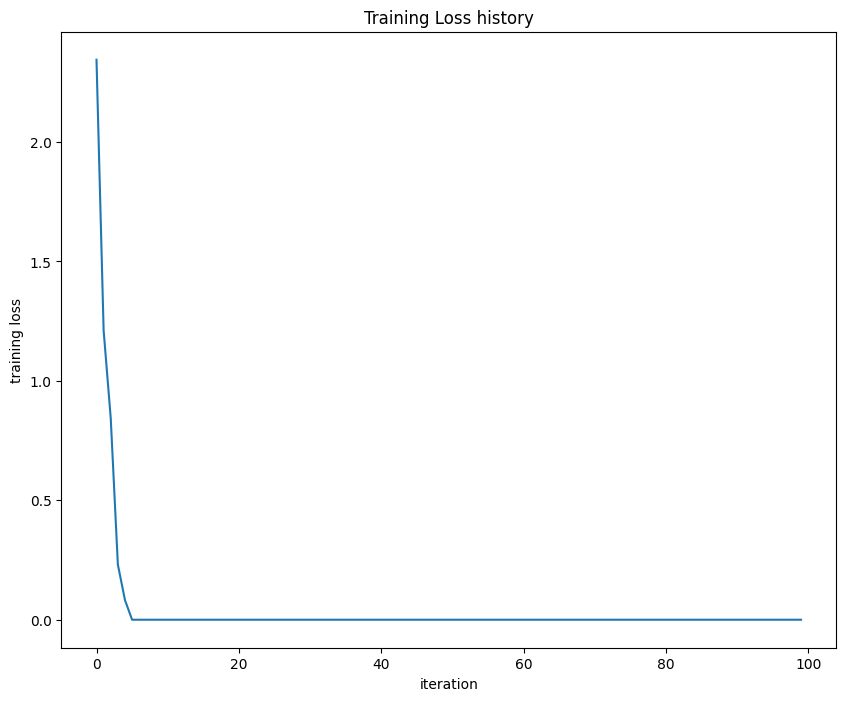

In [26]:
net = init_toy_model()
stats = net.train(X, y, X, y,
            learning_rate=1e-1, reg=5e-6,
            num_iters=100, verbose=False)

print('Final training loss: ', stats['loss_history'][-1])

# plot the loss history
plt.plot(stats['loss_history'])
plt.xlabel('iteration')
plt.ylabel('training loss')
plt.title('Training Loss history')
plt.show()

# Load the data
Now that you have implemented a two-layer network that passes gradient checks and works on toy data, it's time to load up our favorite CIFAR-10 data so we can use it to train a classifier on a real dataset.

In [27]:
from EITB712M.data_utils import load_CIFAR10

def get_CIFAR10_data(num_training=49000, num_validation=1000, num_test=1000):
    """
    Load the CIFAR-10 dataset from disk and perform preprocessing to prepare
    it for the two-layer neural net classifier. These are the same steps as
    we used for the SVM, but condensed to a single function.  
    """
    # Load the raw CIFAR-10 data
    cifar10_dir = 'datasets/cifar-10-batches-py'
    
    # Cleaning up variables to prevent loading data multiple times (which may cause memory issue)
    try:
       del X_train, y_train
       del X_test, y_test
       print('Clear previously loaded data.')
    except:
       pass

    X_train, y_train, X_test, y_test = load_CIFAR10(cifar10_dir)
        
    # Subsample the data
    mask = list(range(num_training, num_training + num_validation))
    X_val = X_train[mask]
    y_val = y_train[mask]
    mask = list(range(num_training))
    X_train = X_train[mask]
    y_train = y_train[mask]
    mask = list(range(num_test))
    X_test = X_test[mask]
    y_test = y_test[mask]

    # Normalize the data: subtract the mean image
    mean_image = np.mean(X_train, axis=0)
    X_train -= mean_image
    X_val -= mean_image
    X_test -= mean_image

    # Reshape data to rows
    X_train = X_train.reshape(num_training, -1)
    X_val = X_val.reshape(num_validation, -1)
    X_test = X_test.reshape(num_test, -1)

    return X_train, y_train, X_val, y_val, X_test, y_test


# Invoke the above function to get our data.
X_train, y_train, X_val, y_val, X_test, y_test = get_CIFAR10_data()
print('Train data shape: ', X_train.shape)
print('Train labels shape: ', y_train.shape)
print('Validation data shape: ', X_val.shape)
print('Validation labels shape: ', y_val.shape)
print('Test data shape: ', X_test.shape)
print('Test labels shape: ', y_test.shape)

Train data shape:  (49000, 3072)
Train labels shape:  (49000,)
Validation data shape:  (1000, 3072)
Validation labels shape:  (1000,)
Test data shape:  (1000, 3072)
Test labels shape:  (1000,)


# Train a network
To train our network we will use SGD. In addition, we will adjust the learning rate with an exponential learning rate schedule as optimization proceeds; after each epoch, we will reduce the learning rate by multiplying it by a decay rate.

In [28]:
input_size = 32 * 32 * 3
hidden_size = 50
num_classes = 10
net = TwoLayerNet(input_size, hidden_size, num_classes)

# Train the network
stats = net.train(X_train, y_train, X_val, y_val,
            num_iters=1000, batch_size=200,
            learning_rate=1e-4, learning_rate_decay=0.95,
            reg=0.25, verbose=True)

# Predict on the validation set
val_acc = (net.predict(X_val) == y_val).mean()
print('Validation accuracy: ', val_acc)


iteration 0 / 1000: loss 8.999845
iteration 100 / 1000: loss 5.862461
iteration 200 / 1000: loss 4.541893
iteration 300 / 1000: loss 4.165386
iteration 400 / 1000: loss 4.692234
iteration 500 / 1000: loss 3.663187
iteration 600 / 1000: loss 3.808446
iteration 700 / 1000: loss 3.075892
iteration 800 / 1000: loss 3.358589
iteration 900 / 1000: loss 3.385532
Validation accuracy:  0.448


# Debug the training
With the default parameters we provided above, you should get a validation accuracy of about 0.4 on the validation set. This isn't very good.

One strategy for getting insight into what's wrong is to plot the loss function and the accuracies on the training and validation sets during optimization.

Another strategy is to visualize the weights that were learned in the first layer of the network. In most neural networks trained on visual data, the first layer weights typically show some visible structure when visualized.

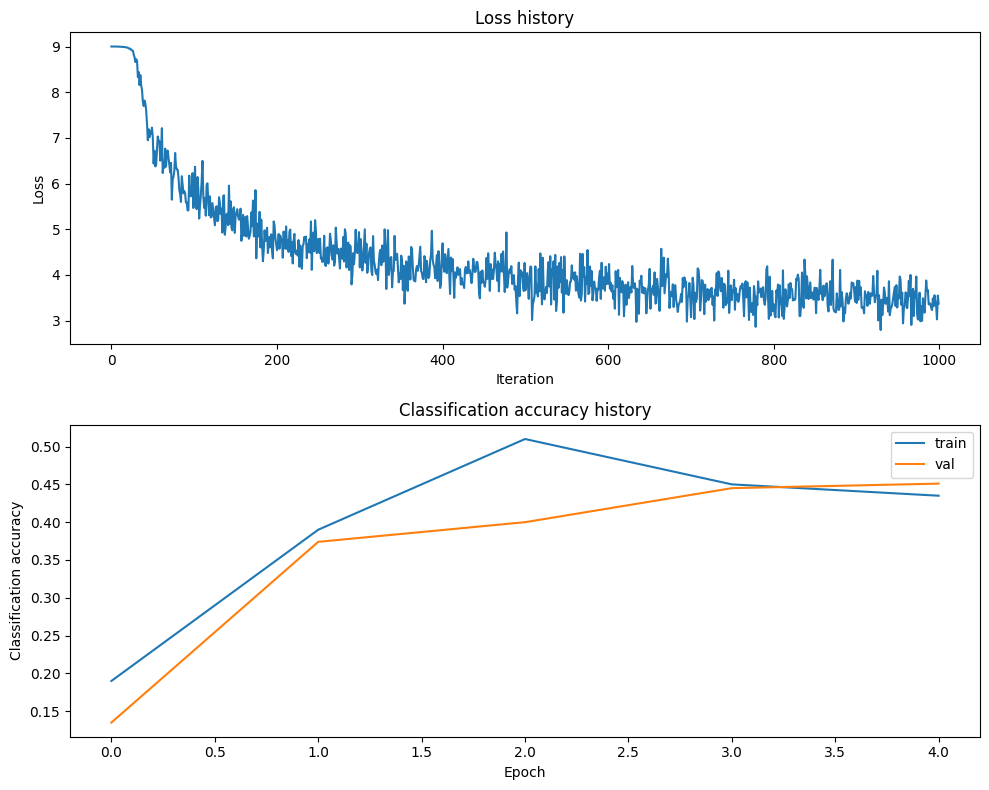

In [29]:
# Plot the loss function and train / validation accuracies
plt.subplot(2, 1, 1)
plt.plot(stats['loss_history'])
plt.title('Loss history')
plt.xlabel('Iteration')
plt.ylabel('Loss')

plt.subplot(2, 1, 2)
plt.plot(stats['train_acc_history'], label='train')
plt.plot(stats['val_acc_history'], label='val')
plt.title('Classification accuracy history')
plt.xlabel('Epoch')
plt.ylabel('Classification accuracy')
plt.legend()
plt.tight_layout()
plt.show()

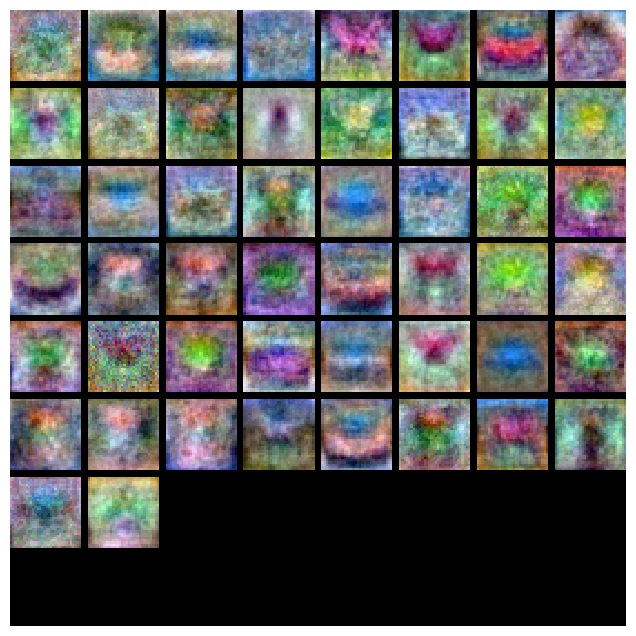

In [30]:
from EITB712M.vis_utils import visualize_grid

# Visualize the weights of the network

def show_net_weights(net):
    W1 = net.params['W1']
    W1 = W1.reshape(32, 32, 3, -1).transpose(3, 0, 1, 2)
    plt.imshow(visualize_grid(W1, padding=3).astype('uint8'))
    plt.gca().axis('off')
    plt.show()

show_net_weights(net)

# Tune your hyperparameters

**What's wrong?**. Looking at the visualizations above, we see that the loss is decreasing more or less linearly, which seems to suggest that the learning rate may be too low. Moreover, there is no gap between the training and validation accuracy, suggesting that the model we used has low capacity, and that we should increase its size. On the other hand, with a very large model we would expect to see more overfitting, which would manifest itself as a very large gap between the training and validation accuracy.

**Tuning**. Tuning the hyperparameters and developing intuition for how they affect the final performance is a large part of using Neural Networks, so we want you to get a lot of practice. Below, you should experiment with different values of the various hyperparameters, including hidden layer size, learning rate, numer of training epochs, and regularization strength. You might also consider tuning the learning rate decay, but you should be able to get good performance using the default value.

**Approximate results**. You should be aim to achieve a classification accuracy of greater than 48% on the validation set. Our best network gets over 52% on the validation set.

**Experiment**: You goal in this exercise is to get as good of a result on CIFAR-10 as you can (52% could serve as a reference), with a fully-connected Neural Network. Feel free implement your own techniques (e.g. PCA to reduce dimensionality, or adding dropout, or adding features to the solver, etc.).

<span style="color:blue">**Explain your hyperparameter tuning process below.**</span>

$\color{blue}{\textit Your Answer:}$

In [33]:
best_net = None # store the best model into this 
best_val = -1
best_stats = []

######################################################################################
# TODO: Tune hyperparameters using the validation set. Store your best trained       #
# model in best_net.                                                                 #
#                                                                                    #
# To help debug your network, it may help to use visualizations similar to the       #
# ones we used above; these visualizations will have significant qualitative         #
# differences from the ones we saw above for the poorly tuned network.               #
#                                                                                    #
# Tweaking hyperparameters by hand can be fun, but you might find it useful to       #
# write code to sweep through possible combinations of hyperparameters               #
# automatically like we did on the previous exercises.                               #
#                                                                                    #
# Note: The hyperparameter tuning requires a lot of computer power and take a while! #
######################################################################################

# generate random hyperparameters given ranges for each of them
def generate_random_hyperparams(lr_min, lr_max, reg_min, reg_max, h_min, h_max):
    lr = 10**np.random.uniform(lr_min,lr_max)
    reg = 10**np.random.uniform(reg_min,reg_max)
    hidden = np.random.randint(h_min, h_max)
    return lr, reg, hidden

# get random hyperparameters given arrays of potential values
def random_search_hyperparams(lr_values, reg_values, h_values):
    lr = lr_values[np.random.randint(0,len(lr_values))]
    reg = reg_values[np.random.randint(0,len(reg_values))]
    hidden = h_values[np.random.randint(0,len(h_values))]
    return lr, reg, hidden

input_size = 32 * 32 * 3
num_classes = 10

# Set a seed for results reproduction
np.random.seed(0)

# Use of random search for hyperparameter search
for i in range(20):
    ## Strategy to find the best hyperparameters over 52% on the validation set
    # Use generate_random function given some interval with 500 iterations
    lr, reg, hidden_size = generate_random_hyperparams(-6, -3, -5, 5, 20, 3000)
    
    # According to the previous results, reduce the exploration by selecting set of fixed ranges
    # use this ranges in the random search function to explore random combinations
    #lr, reg, hidden_size = random_search_hyperparams([0.001], [0.1, 0.15, 0.2, 0.3], [10, 20, 30, 40 ,50, 80, 100, 150 , 200])    
    
    # Given a set of potential values, increase the number of iterations
    #lr, reg, hidden_size = random_search_hyperparams([0.001], [0.05, 0.1, 0.15], [50, 80, 100, 120, 150, 180, 200])
    
    # Create a two-layer network
    net = TwoLayerNet(input_size, hidden_size, num_classes)
    
    # Train the network
    stats = net.train(X_train, y_train, X_val, y_val,
                num_iters=2500, batch_size=200,
                learning_rate=lr, learning_rate_decay=0.95,
                reg=reg, verbose=False)

    # Predict on the training set
    train_accuracy = (net.predict(X_train) == y_train).mean()
    
    # Predict on the validation set
    val_accuracy = (net.predict(X_val) == y_val).mean()
    
    # Save best values
    if val_accuracy > best_val:
        best_val = val_accuracy
        best_train = train_accuracy
        best_net = net
        best_stats = stats
    
    # Print results
    print('lr %e reg %e hid %d  train accuracy: %f val accuracy: %f' % (
                lr, reg, hidden_size, train_accuracy, val_accuracy))
print('best validation accuracy achieved: %f' % best_val)
print('best train accuracy achieved: %f' % best_train)

lr 4.430375e-05 reg 1.418710e+02 hid 855  train accuracy: 0.466143 val accuracy: 0.468000
lr 9.869630e-04 reg 3.461741e+02 hid 2129  train accuracy: 0.390755 val accuracy: 0.381000
lr 1.907539e-05 reg 2.876193e-04 hid 2505  train accuracy: 0.429000 val accuracy: 0.438000
lr 2.572751e-04 reg 6.634256e+03 hid 788  train accuracy: 0.350163 val accuracy: 0.364000
lr 2.052703e-05 reg 2.435182e+01 hid 1131  train accuracy: 0.426224 val accuracy: 0.434000
lr 4.804692e-05 reg 4.187721e-02 hid 197  train accuracy: 0.484082 val accuracy: 0.484000
lr 2.906186e-05 reg 3.029737e+04 hid 434  train accuracy: 0.293612 val accuracy: 0.309000
lr 4.240269e-06 reg 1.316873e+04 hid 2372  train accuracy: 0.220449 val accuracy: 0.229000
lr 2.290252e-04 reg 2.053000e-03 hid 2875  train accuracy: 0.631592 val accuracy: 0.525000
lr 3.076556e-06 reg 7.564579e+01 hid 489  train accuracy: 0.263510 val accuracy: 0.269000
lr 5.339704e-04 reg 9.835416e-05 hid 1767  train accuracy: 0.629735 val accuracy: 0.507000
lr 2

In [34]:
# Print your validation accuracy: this should be above 48%
val_acc = (best_net.predict(X_val) == y_val).mean()
print('Validation accuracy: ', val_acc)

Validation accuracy:  0.526


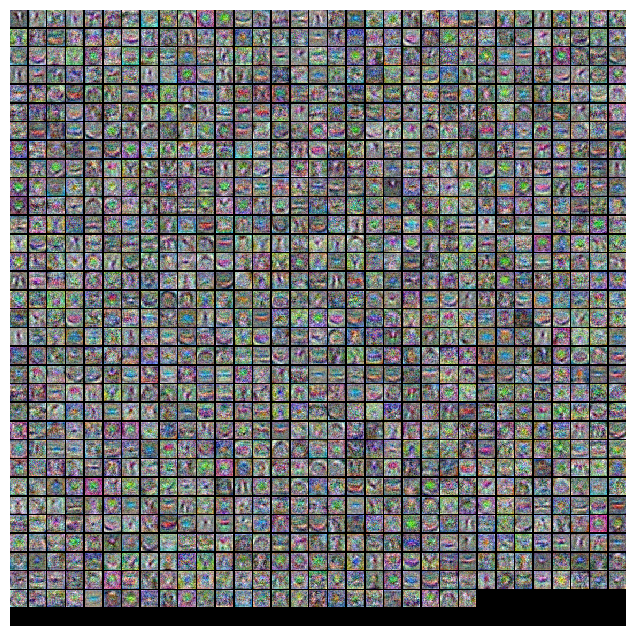

In [35]:
# Visualize the weights of the best network
show_net_weights(best_net)

# Run on the test set
When you are done experimenting, you should evaluate your final trained network on the test set; you should get above 48%.

In [36]:
# Print your test accuracy: this should be above 48%
test_acc = (best_net.predict(X_test) == y_test).mean()
print('Test accuracy: ', test_acc)

Test accuracy:  0.543


**Inline Question**

Now that you have trained a Neural Network classifier, you may find that your testing accuracy is much lower than the training accuracy. In what ways can we decrease this gap? Select all that apply.

1. Train on a larger dataset.
2. Add more hidden units.
3. Increase the regularization strength.
4. None of the above.

$\color{blue}{\textit Your Answer:}$

> - Mehr Daten führt zu besser generalisierung und weniger overfitting
> - mehr layer helfen nicht. verstärkt overfitting
> - Höherer Regularisierungwert bestraft große weights noch stärker.

$\color{blue}{\textit Your Explanation:}$

> siehe oben


In [ ]:
import helpers

helpers.prepare_submission(additional=[r"EITB712M\classifiers\neural_net.py", r"EITB712M\gradient_check.py", r"EITB712M\vis_utils.py", r"EITB712M\data_utils.py", r"datasets\cifar-10-batches-py"])